<a href="https://colab.research.google.com/github/AshrfCode/Anan-Tirgulem/blob/main/Tut6_SearchingEngine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
!pip install requests beautifulsoup4 firebase-admin nltk pandas matplotlib

In [108]:
import requests
from bs4 import BeautifulSoup
import re
import firebase_admin
from firebase_admin import credentials, db
from nltk.stem import PorterStemmer
import pandas as pd
import matplotlib.pyplot as plt

In [109]:
cred = credentials.Certificate("search-engine-project-43eb6-firebase-adminsdk-fbsvc-814a03c28a (1).json")

try:
    firebase_admin.delete_app(firebase_admin.get_app())
except:
    pass

firebase_admin.initialize_app(cred, {
    "databaseURL": "https://search-engine-project-43eb6-default-rtdb.firebaseio.com/"
})

In [110]:
def fetch_page(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        return BeautifulSoup(response.text, "html.parser")
    else:
        print("Error:", response.status_code)
        return None

In [111]:
def index_words(soup):
    index = {}
    words = re.findall(r"\w+", soup.get_text())

    for word in words:
        word = word.lower()

        if word.isalpha():
            if word in index:
                index[word] += 1
            else:
                index[word] = 1

    return index

In [112]:
def remove_stop_words(index):
    stop_words = {
        "a", "an", "the", "and", "or",
        "in", "on", "at", "to", "for",
        "of", "with", "is", "are", "by",
        "as", "from", "this", "that",
        "be", "it", "they", "their", "was",
        "were", "which", "also", "not", "can"
    }

    for stop_word in stop_words:
        if stop_word in index:
            del index[stop_word]

    return index

In [113]:
def apply_stemming(index):
    stemmer = PorterStemmer()
    stemmed_index = {}

    for word, count in index.items():
        stemmed_word = stemmer.stem(word)

        if stemmed_word in stemmed_index:
            stemmed_index[stemmed_word] += count
        else:
            stemmed_index[stemmed_word] = count

    return stemmed_index

In [126]:
url = "https://en.wikipedia.org/wiki/Plant_disease"

target_words = [
    "plant",
    "diseas",
    "leaf",
    "infect",
    "fungu",
    "bacteria",
    "virus",
    "symptom",
    "detect",
    "crop"
]

soup = fetch_page(url)

index = index_words(soup)
index = remove_stop_words(index)
index = apply_stemming(index)

firebase_index = {}

for word in target_words:
    firebase_index[word] = {
        "count": index.get(word, 0),
        "links": [url]
    }

print(firebase_index)

{'plant': {'count': 105, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'diseas': {'count': 42, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'leaf': {'count': 7, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'infect': {'count': 8, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'fungu': {'count': 7, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'bacteria': {'count': 11, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'virus': {'count': 7, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'symptom': {'count': 1, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'detect': {'count': 3, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'crop': {'count': 11, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}}


In [127]:
ref = db.reference("plant_disease_index")
ref.set(firebase_index)
data = ref.get()
print(data)


{'bacteria': {'count': 11, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'crop': {'count': 11, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'detect': {'count': 3, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'diseas': {'count': 42, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'fungu': {'count': 7, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'infect': {'count': 8, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'leaf': {'count': 7, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'plant': {'count': 105, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'symptom': {'count': 1, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}, 'virus': {'count': 7, 'links': ['https://en.wikipedia.org/wiki/Plant_disease']}}


In [128]:
rows = []

for word, info in data.items():
    rows.append({
        "word": word,
        "count": info["count"],
        "links": ", ".join(info["links"])
    })

df = pd.DataFrame(rows)
df

,word,count,links
0,bacteria,11,https://en.wikipedia.org/wiki/Plant_disease
1,crop,11,https://en.wikipedia.org/wiki/Plant_disease
2,detect,3,https://en.wikipedia.org/wiki/Plant_disease
3,diseas,42,https://en.wikipedia.org/wiki/Plant_disease
4,fungu,7,https://en.wikipedia.org/wiki/Plant_disease
5,infect,8,https://en.wikipedia.org/wiki/Plant_disease
6,leaf,7,https://en.wikipedia.org/wiki/Plant_disease
7,plant,105,https://en.wikipedia.org/wiki/Plant_disease
8,symptom,1,https://en.wikipedia.org/wiki/Plant_disease
9,virus,7,https://en.wikipedia.org/wiki/Plant_disease


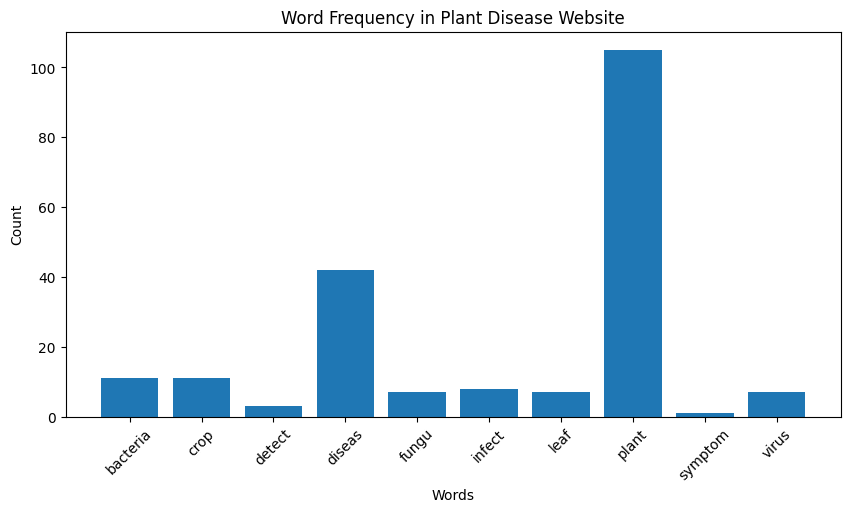

In [129]:
plt.figure(figsize=(10, 5))
plt.bar(df["word"], df["count"])

plt.title("Word Frequency in Plant Disease Website")
plt.xlabel("Words")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()